<a href="https://colab.research.google.com/github/mtarek137/pytorch-mnist-mlp-classifier/blob/main/01_pytorch_mnist_mlp_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


Epoch [1/10], Step [100/600], Loss: 0.4802
Epoch [1/10], Step [200/600], Loss: 0.4202
Epoch [1/10], Step [300/600], Loss: 0.3636
Epoch [1/10], Step [400/600], Loss: 0.2316
Epoch [1/10], Step [500/600], Loss: 0.2128
Epoch [1/10], Step [600/600], Loss: 0.2554
--> Epoch [1/10] Finished | Test Accuracy: 93.45%

Epoch [2/10], Step [100/600], Loss: 0.3641
Epoch [2/10], Step [200/600], Loss: 0.1500
Epoch [2/10], Step [300/600], Loss: 0.2080
Epoch [2/10], Step [400/600], Loss: 0.1561
Epoch [2/10], Step [500/600], Loss: 0.1298
Epoch [2/10], Step [600/600], Loss: 0.1880
--> Epoch [2/10] Finished | Test Accuracy: 94.93%

Epoch [3/10], Step [100/600], Loss: 0.1324
Epoch [3/10], Step [200/600], Loss: 0.1963
Epoch [3/10], Step [300/600], Loss: 0.1053
Epoch [3/10], Step [400/600], Loss: 0.1928
Epoch [3/10], Step [500/600], Loss: 0.0788
Epoch [3/10], Step [600/600], Loss: 0.1875
--> Epoch [3/10] Finished | Test Accuracy: 95.98%

Epoch [4/10], Step [100/600], Loss: 0.0690
Epoch [4/10], Step [200/600], 

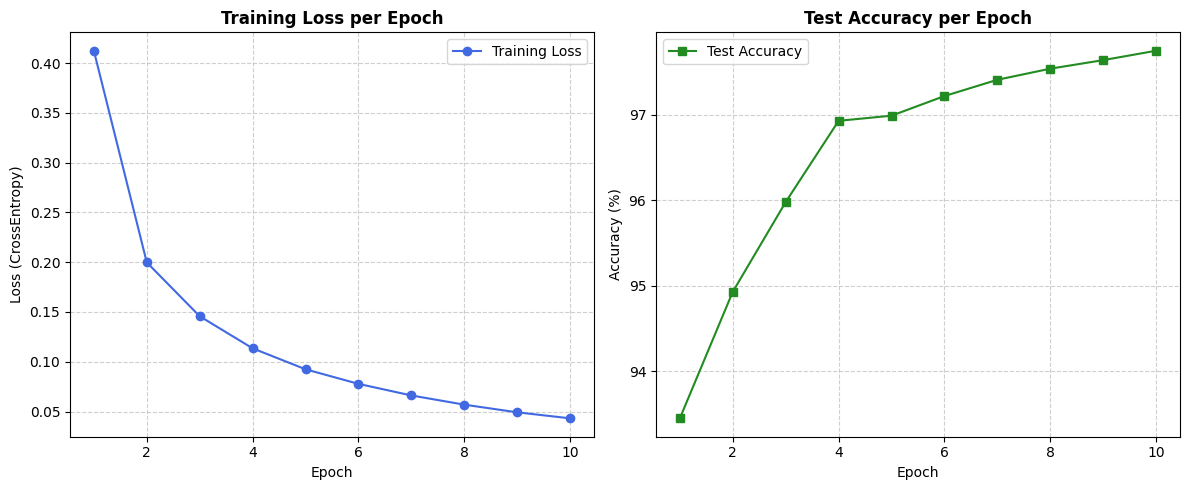

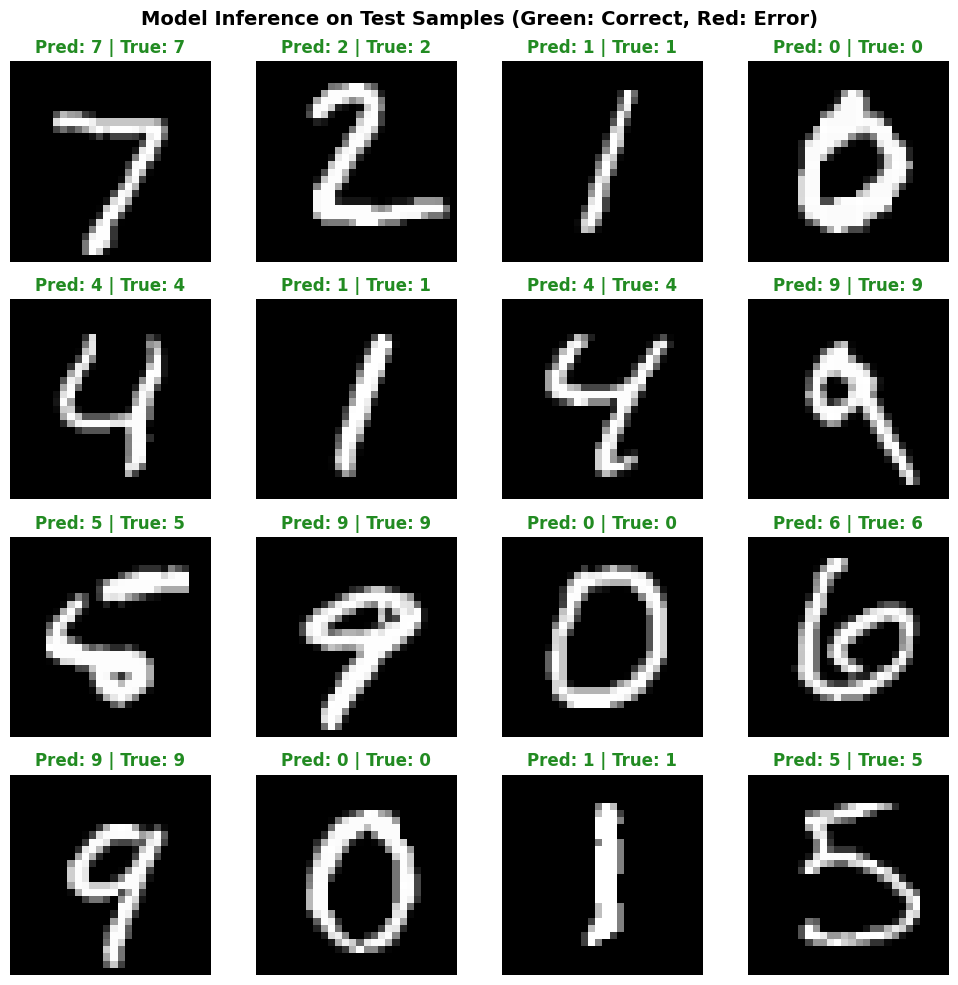

Model weights successfully saved to 'mnist_mlp_weights.pth'


In [1]:
# MNIST Multi-Layer Perceptron

# 1. Imports
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# 2. Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 3. Hyperparameters
input_size = 784  #28*28
hidden_size = 100
no_classes = 10
batch_size = 100
no_epochs = 10
learning_rate = 0.001

# 4. Data Preparation
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transforms.ToTensor(), download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transforms.ToTensor()
)

train_loader=torch.utils.data.DataLoader(
    dataset=train_dataset,batch_size=batch_size,shuffle=True
)
test_loader=torch.utils.data.DataLoader(
    dataset=test_dataset,batch_size=batch_size,shuffle=False
)


# 5. Model Architecture
class NeuralNet(nn.Module):

  def __init__(self, input_size, hidden_size, no_classes):
    super(NeuralNet, self).__init__()
    self.l1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.l2 = nn.Linear(hidden_size, no_classes)

  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    return out


model = NeuralNet(input_size, hidden_size, no_classes).to(device)

# 6. Loss & Optimizer
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Tracking metrics across epochs
epoch_losses = []
epoch_accuracies = []

# 7. Training & Validation Loop
no_total_steps = len(train_loader)

for epoch in range(no_epochs):
  model.train()
  running_loss = 0.0

  for i, (images, labels) in enumerate(train_loader):
    images = images.reshape(-1, 28 * 28).to(device)
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)
    l = loss(outputs, labels)

    # Backward pass & optimize
    optimizer.zero_grad()
    l.backward()
    optimizer.step()

    running_loss += l.item()

    if (i + 1) % 100 == 0:
      print(
          f'Epoch [{epoch+1}/{no_epochs}], Step [{i+1}/{no_total_steps}], Loss:'
          f' {l.item():.4f}'
      )

  # Calculate average loss for the epoch
  avg_epoch_loss = running_loss / no_total_steps
  epoch_losses.append(avg_epoch_loss)

  # Evaluate test accuracy after each epoch
  model.eval()
  n_correct, n_samples = 0, 0
  with torch.no_grad():
    for images, labels in test_loader:
      images = images.reshape(-1, 28 * 28).to(device)
      labels = labels.to(device)
      outputs = model(images)
      _, prediction = torch.max(outputs, 1)
      n_samples += labels.shape[0]
      n_correct += (prediction == labels).sum().item()

  current_acc = 100.0 * n_correct / n_samples
  epoch_accuracies.append(current_acc)
  print(
      f'--> Epoch [{epoch+1}/{no_epochs}] Finished | Test Accuracy:'
      f' {current_acc:.2f}%\n'
  )

print(f'Final Test Accuracy: {epoch_accuracies[-1]:.2f}%\n')

# Plotting, Prediction Visuals


# 8. Plot Loss & Accuracy Learning Curves
epochs_range = range(1, no_epochs + 1)
plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    epoch_losses,
    marker='o',
    color='royalblue',
    label='Training Loss',
)
plt.title('Training Loss per Epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (CrossEntropy)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    epoch_accuracies,
    marker='s',
    color='forestgreen',
    label='Test Accuracy',
)
plt.title('Test Accuracy per Epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# 9. Visual Evaluation Grid (Predicted vs Actual)
examples = iter(test_loader)
sample_images, sample_labels = next(examples)

model.eval()
with torch.no_grad():
  flattened_samples = sample_images.reshape(-1, 28 * 28).to(device)
  raw_outputs = model(flattened_samples)
  _, predicted_classes = torch.max(raw_outputs, 1)

plt.figure(figsize=(10, 10))
for i in range(16):
  plt.subplot(4, 4, i + 1)
  # Squeeze out the channel dimension: (1, 28, 28) -> (28, 28)
  plt.imshow(sample_images[i].squeeze(), cmap='gray')

  pred = predicted_classes[i].item()
  truth = sample_labels[i].item()

  # Match = Green, Mismatch = Red
  is_correct = pred == truth
  color = 'forestgreen' if is_correct else 'crimson'

  plt.title(f'Pred: {pred} | True: {truth}', color=color, fontweight='bold')
  plt.axis('off')

plt.suptitle(
    'Model Inference on Test Samples (Green: Correct, Red: Error)',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

# 10. Save the Trained Model Weights
# Model Saving
torch.save(model.state_dict(), 'mnist_mlp_weights.pth')
print("Model weights successfully saved to 'mnist_mlp_weights.pth'")